# NVDA–TSLA Spread Prediction and Long–Short Backtest

This notebook is a clean end-to-end runner for the project:

- inspect the raw `mag7.pickle` data,
- visualize NVDA, TSLA, and the realized spread series,
- document the model and feature specifications,
- run all four models,
- evaluate classification fit,
- evaluate portfolio performance against benchmarks,
- plot training and testing performance together and separately.

In [1]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Make sure imports work whether the notebook is launched from the repo root
# or from the notebooks/ folder.
ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from src import config
from src.data import load_raw_data, filter_pair, add_daily_returns
from src.features import add_accounting_features, add_technical_features, build_pair_dataset
from src.engine import make_dataset, build_rolling_windows, run_all_experiments
from src.backtest import wealth_index

print("ROOT =", ROOT)
print("Raw data path =", config.RAW_DATA_PATH)


ROOT = /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project
Raw data path = /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/data/raw/mag7.pickle


## 1. Load and inspect the data

In [2]:
raw = load_raw_data(config.RAW_DATA_PATH)
pair_raw = filter_pair(raw, config.SYMBOL_A, config.SYMBOL_B).copy()
pair_raw = add_daily_returns(pair_raw)

pair_dataset = make_dataset()

summary = pd.DataFrame({
    "stat": [
        "raw rows",
        "raw cols",
        "pair rows",
        "pair cols",
        "pair start",
        "pair end",
        "symbols",
    ],
    "value": [
        raw.shape[0],
        raw.shape[1],
        pair_dataset.shape[0],
        pair_dataset.shape[1],
        pair_dataset["date"].min().date(),
        pair_dataset["date"].max().date(),
        ", ".join(sorted(pair_raw["symbol"].unique())),
    ]
})

display(summary)


,stat,value
0,raw rows,27391
1,raw cols,93
2,pair rows,3839
3,pair cols,21
4,pair start,2010-09-28
5,pair end,2025-12-30
6,symbols,"NVDA, TSLA"


In [3]:
coverage = (
    pair_raw.groupby("symbol")
    .agg(
        n_obs=("date", "size"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        min_close=("close_adj", "min"),
        max_close=("close_adj", "max"),
    )
    .reset_index()
)

display(coverage)
display(pair_raw.head())
display(pair_dataset.head())


,symbol,n_obs,start_date,end_date,min_close,max_close
0,NVDA,4025,2010-01-04,2025-12-31,0.2221,207.0290
1,TSLA,3903,2010-06-29,2025-12-31,1.0533,489.8800


,symbol,date,close_adj,volume,datadate,actq,ajexq,atq,capxy,ceqq,chechy,cheq,cogsq,cogsy,csh12q,cshfdq,cshiq,cshopq,cshoq,cshprq,cstkq,curcdq,datacqtr,datafqtr,dlcq,dltisy,dltry,dlttq,dpcy,dpq,dvpq,dvpspq,dvy,epsf12,epsfi12,epsfiq,epsfxq,epspi12,epspiq,epspxq,epsx12,fqtr,fyearq,fyr,ibadjq,ibcomq,ibcomy,ibcy,ibq,icaptq,invtq,lctq,ltq,mibq,miiq,miiy,niq,nopiq,oancfy,oepf12,oeps12,oepsxq,oepsxy,oiadpq,oiadpy,oibdpq,oibdpy,piq,ppentq,pstkq,pstkrq,rectq,req,revtq,revty,saleq,seqq,spiq,teqq,txdbq,txditcq,txpdy,txpq,txtq,xidocy,xidoy,xintq,xinty,xoprq,xrdq,xrdy,xsgaq,xsgay,ret_1d
0,NVDA,2010-01-04,0.4622,"20,156,410.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,USD,2009Q3,2009Q3,0.9280,0.0000,0.0000,24.7600,148.7500,48.7700,0.0000,0.0000,0.0000,-0.6300,-0.6300,0.1900,0.1900,-0.6300,0.2000,0.2000,-0.6300,3,2009,1,107.5770,107.5770,-199.0630,-199.0630,107.5770,"2,448.3950",277.6430,888.8060,"1,039.9390",0.0000,0.0000,0.0000,107.5770,2.3620,418.5620,-0.2900,-0.2900,0.1400,-0.0300,82.7400,0.9630,131.5100,149.7130,110.2070,565.2960,0.0000,0.0000,397.8200,"1,774.7510",903.2060,"2,343.9570",903.2060,"2,423.6350",25.1050,"2,423.6350",0.0000,57.0530,2.6110,0.0000,2.6300,0.0000,0.0000,0.0540,0.0540,771.6960,197.9480,692.6000,236.1580,695.7790,<NA>
1,NVDA,2010-01-05,0.4690,"18,292,140.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,USD,2009Q3,2009Q3,0.9280,0.0000,0.0000,24.7600,148.7500,48.7700,0.0000,0.0000,0.0000,-0.6300,-0.6300,0.1900,0.1900,-0.6300,0.2000,0.2000,-0.6300,3,2009,1,107.5770,107.5770,-199.0630,-199.0630,107.5770,"2,448.3950",277.6430,888.8060,"1,039.9390",0.0000,0.0000,0.0000,107.5770,2.3620,418.5620,-0.2900,-0.2900,0.1400,-0.0300,82.7400,0.9630,131.5100,149.7130,110.2070,565.2960,0.0000,0.0000,397.8200,"1,774.7510",903.2060,"2,343.9570",903.2060,"2,423.6350",25.1050,"2,423.6350",0.0000,57.0530,2.6110,0.0000,2.6300,0.0000,0.0000,0.0540,0.0540,771.6960,197.9480,692.6000,236.1580,695.7790,0.0146
2,NVDA,2010-01-06,0.4720,"16,315,670.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,USD,2009Q3,2009Q3,0.9280,0.0000,0.0000,24.7600,148.7500,48.7700,0.0000,0.0000,0.0000,-0.6300,-0.6300,0.1900,0.1900,-0.6300,0.2000,0.2000,-0.6300,3,2009,1,107.5770,107.5770,-199.0630,-199.0630,107.5770,"2,448.3950",277.6430,888.8060,"1,039.9390",0.0000,0.0000,0.0000,107.5770,2.3620,418.5620,-0.2900,-0.2900,0.1400,-0.0300,82.7400,0.9630,131.5100,149.7130,110.2070,565.2960,0.0000,0.0000,397.8200,"1,774.7510",903.2060,"2,343.9570",903.2060,"2,423.6350",25.1050,"2,423.6350",0.0000,57.0530,2.6110,0.0000,2.6300,0.0000,0.0000,0.0540,0.0540,771.6960,197.9480,692.6000,236.1580,695.7790,0.0064
3,NVDA,2010-01-07,0.4628,"13,796,019.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,USD,2009Q3,2009Q3,0.9280,0.0000,0.0000,24.7600,148.7500,48.7700,0.0000,0.0000,0.0000,-0.6300,-0.6300,0.1900,0.1900,-0.6300,0.2000,0.2000,-0.6300,3,2009,1,107.5770,107.5770,-199.0630,-199.0630,107.5770,"2,448.3950",277.6430,888.8060,"1,039.9390",0.0000,0.0000,0.0000,107.5770,2.3620,418.5620,-0.2900,-0.2900,0.1400,-0.0300,82.7400,0.9630,131.5100,149.7130,110.2070,565.2960,0.0000,0.0000,397.8200,"1,774.7510",903.2060,"2,343.9570",903.2060,"2,423.6350",25.1050,"2,423.6350",0.0000,57.0530,2.6110,0.0000,2.6300,0.0000,0.0000,0.0540,0.0540,771.6960,197.9480,692.6000,236.1580,695.7790,-0.0196
4,NVDA,2010-01-08,0.4637,"12,061,066.0000",2009-10-31,"2,357.7160",40.0000,"3,463.5740",55.0260,"2,423.6350",196.8020,"1,634.0790",535.5380,"1,498.4650",544.4515,574.3810,645.8260,0.0000,554.9000,551.2830,0.6460,U

,date,ret_a_next,ret_b_next,spread_t,spread_next,op_margin_diff,net_margin_diff,leverage_diff,cash_ratio_diff,rnd_intensity_diff,capex_intensity_diff,asset_turnover_diff,log_mcap_diff,mom5_diff,mom21_diff,mom63_diff,ma_gap20_diff,rsi14_diff,rv21_diff,vol_shock20_diff,y_binary
0,2010-09-28,-0.0076,0.0271,-0.0444,-0.0347,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2562,0.0300,0.0966,0.2465,0.0876,24.9394,-0.0396,-0.6863,0
1,2010-09-29,-0.0167,-0.0717,-0.0347,0.0550,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2218,-0.0632,0.1262,0.2412,0.0441,22.0264,-0.0902,-0.7517,1
2,2010-09-30,-0.0284,0.0096,0.0550,-0.0380,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2793,-0.0379,0.2053,0.1962,0.0901,25.6947,-0.1717,-0.9633,0
3,2010-10-01,-0.0097,0.0189,-0.0380,-0.0286,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2410,-0.0991,0.2000,0.0344,0.0407,13.4926,-0.1212,0.5376,0
4,2010-10-04,0.0071,0.0062,-0.0286,0.0009,1.1271,1.1822,-0.3066,0.1554,-0.2831,-0.1048,0.0254,0.2125,-0.0853,0.1778,-0.1944,0.0055,13.3189,-0.1110,0.1803,1


In [4]:
missing_pair = pair_dataset.isna().sum().sort_values(ascending=False)
display(missing_pair[missing_pair > 0].to_frame("n_missing"))


,n_missing


### Basic price and return visualization

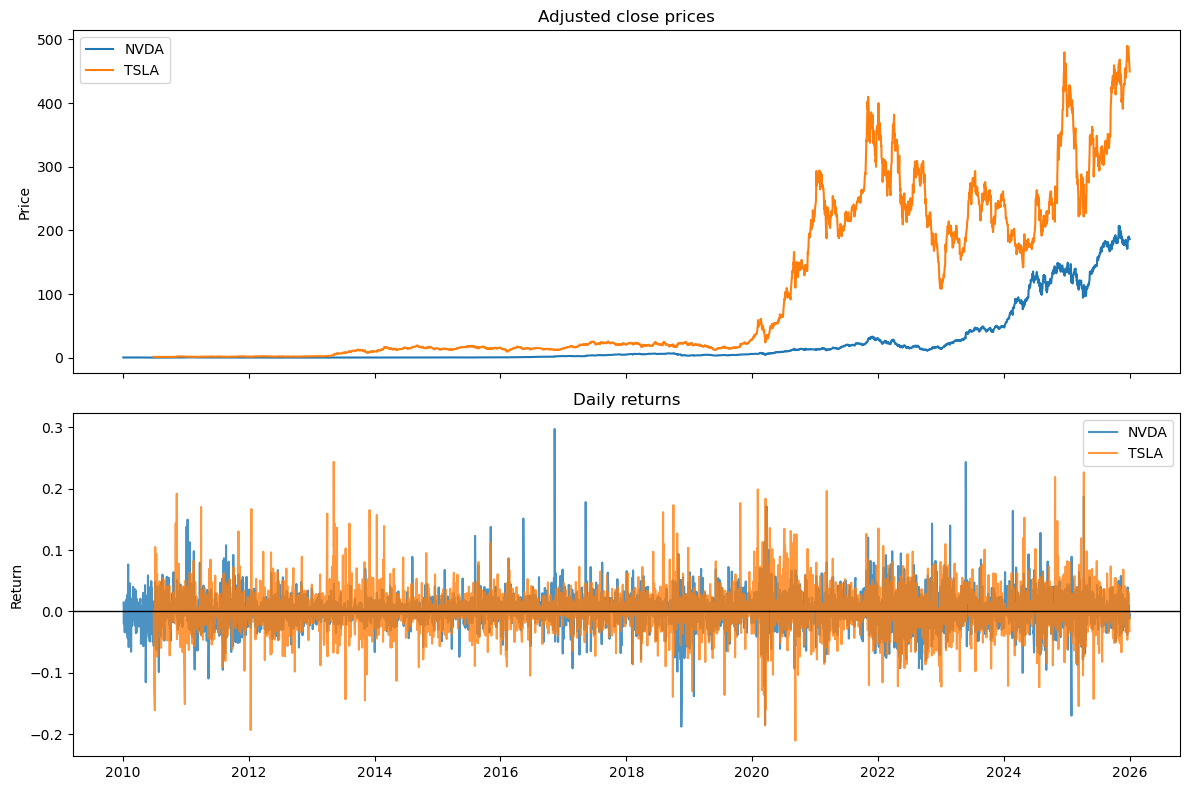

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for symbol, sub in pair_raw.groupby("symbol"):
    sub = sub.sort_values("date")
    axes[0].plot(sub["date"], sub["close_adj"], label=symbol)
    axes[1].plot(sub["date"], sub["ret_1d"], label=symbol, alpha=0.8)

axes[0].set_title("Adjusted close prices")
axes[0].set_ylabel("Price")
axes[0].legend()

axes[1].set_title("Daily returns")
axes[1].set_ylabel("Return")
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].legend()

plt.tight_layout()
plt.show()


### Realized spread over the entire sample

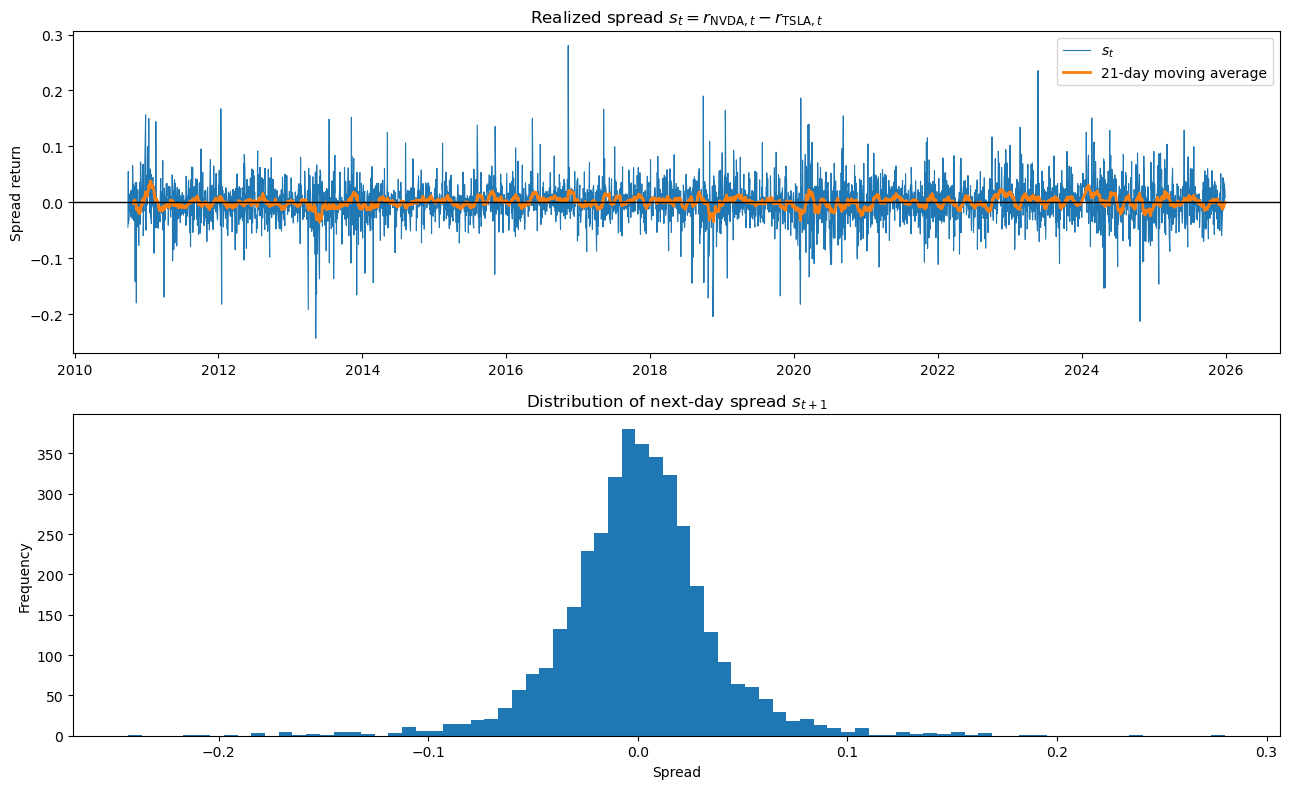

In [33]:
spread_plot = pair_dataset[["date", "spread_t", "spread_next"]].copy()
spread_plot["spread_t_21d_ma"] = spread_plot["spread_t"].rolling(21).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(spread_plot["date"], spread_plot["spread_t"], linewidth=0.8, label=r"$s_t$")
axes[0].plot(spread_plot["date"], spread_plot["spread_t_21d_ma"], linewidth=2.0, label="21-day moving average")
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title(r"Realized spread $s_t = r_{\mathrm{NVDA},t} - r_{\mathrm{TSLA},t}$")
axes[0].set_ylabel("Spread return")
axes[0].legend()

axes[1].hist(spread_plot["spread_next"].dropna(), bins=80)
axes[1].set_title(r"Distribution of next-day spread $s_{t+1}$")
axes[1].set_xlabel("Spread")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
sign_table = pd.DataFrame({
    "count": pair_dataset["y_binary"].value_counts().sort_index(),
})
sign_table.index = ["spread_next <= 0", "spread_next > 0"]
sign_table["share"] = sign_table["count"] / sign_table["count"].sum()

display(sign_table)

display(pair_dataset[["spread_t", "spread_next"]].describe().T)


,count,share
spread_next <= 0,1909,0.4973
spread_next > 0,1930,0.5027


,count,mean,std,min,25%,50%,75%,max
spread_t,"3,839.0000",-0.0001,0.0368,-0.2432,-0.0187,0.0002,0.0187,0.2802
spread_next,"3,839.0000",-0.0001,0.0368,-0.2432,-0.0186,0.0002,0.0187,0.2802


## 2. Model, target, feature, and backtest specification

### 2.1 Daily return and spread

Let \(P_{i,t}\) be the adjusted close of stock \(i\) on day \(t\). Daily return is

$$
r_{i,t}=\frac{P_{i,t}}{P_{i,t-1}}-1.
$$

For the stock pair \((\text{NVDA}, \text{TSLA})\), the spread return is

$$
s_t=r_{\text{NVDA},t}-r_{\text{TSLA},t}.
$$

The prediction target is based on the **next-day spread** \(s_{t+1}\).

### 2.2 Binary target

For the binary models,

$$
y^{\text{bin}}_t=\mathbf{1}\{s_{t+1}>0\}.
$$

The trading signal from the binary classifier is

$$
d_t=
\begin{cases}
1, & \hat p_t>0.5,\\
0, & \hat p_t=0.5,\\
-1, & \hat p_t<0.5,
\end{cases}
$$

where \(\hat p_t=\Pr(y_t^{\text{bin}}=1\mid x_t)\).

### 2.3 Multiclass target

For the multiclass models, define the train-window threshold

$$
q_{\text{train}} = \text{Quantile}_{\tau}\big(|s_{t+1}|\big),
$$

where \(\tau\) is the train-window quantile chosen in `config.MULTICLASS_ABS_QUANTILE`.

Then the target is

$$
y^{\text{multi}}_t=
\begin{cases}
1, & s_{t+1}\ge q_{\text{train}},\\
-1, & s_{t+1}\le -q_{\text{train}},\\
0, & |s_{t+1}|<q_{\text{train}}.
\end{cases}
$$

The multiclass signal is the predicted class itself:

$$
d_t=\hat y^{\text{multi}}_t\in\{-1,0,1\}.
$$

### 2.4 Feature construction

Each feature is built as a **cross-sectional difference**

$$
x_{k,t}=f_{k,\text{NVDA},t}-f_{k,\text{TSLA},t}.
$$

The accounting features are:

- operating margin:
$$
\text{op\_margin}=\frac{\text{oiadpq}}{\text{saleq}}
$$

- net margin:
$$
\text{net\_margin}=\frac{\text{niq}}{\text{saleq}}
$$

- leverage:
$$
\text{leverage}=\frac{\text{dlttq}+\text{dlcq}}{\text{atq}}
$$

- cash ratio:
$$
\text{cash\_ratio}=\frac{\text{cheq}}{\text{atq}}
$$

- R\&D intensity:
$$
\text{rnd\_intensity}=\frac{\text{xrdq}}{\text{saleq}}
$$

- capex intensity:
$$
\text{capex\_intensity}=\frac{\text{capxy}}{\text{atq}}
$$

- asset turnover:
$$
\text{asset\_turnover}=\frac{\text{saleq}}{\text{atq}}
$$

- log market cap:
$$
\log(\text{close\_adj}\times \text{cshoq})
$$

The technical features are:

- 5-day momentum:
$$
\text{mom5}_t=\frac{P_t}{P_{t-5}}-1
$$

- 21-day momentum:
$$
\text{mom21}_t=\frac{P_t}{P_{t-21}}-1
$$

- 63-day momentum:
$$
\text{mom63}_t=\frac{P_t}{P_{t-63}}-1
$$

- 20-day moving-average gap:
$$
\text{ma\_gap20}_t=\frac{P_t}{\text{MA}_{20,t}}-1
$$

- 14-day RSI:
$$
\text{RSI}_{14,t}=100-\frac{100}{1+\text{RS}_{14,t}}
$$

- 21-day realized volatility:
$$
\text{rv21}_t=\sqrt{252}\,\text{sd}(r_{t-20},\dots,r_t)
$$

- volume shock:
$$
\text{vol\_shock20}_t=\log\left(\frac{\text{volume}_t}{\text{MA}_{20}(\text{volume})_t}\right).
$$

### 2.5 Model specifications

#### Logistic regression

Binary logistic regression uses

$$
\Pr(y_t=1\mid x_t)=\Lambda(\alpha+x_t^\top\beta),
$$

where

$$
\Lambda(z)=\frac{1}{1+e^{-z}}.
$$

For multiclass logistic regression, the model uses a multinomial softmax over the three classes.

#### Neural network

The neural network is a simple multi-layer perceptron classifier:

$$
h_t = \phi(W_1 x_t + b_1), \qquad
\hat y_t = g(W_2 h_t + b_2),
$$

where \(\phi(\cdot)\) is the hidden-layer activation and \(g(\cdot)\) is the final sigmoid or softmax output layer.

### 2.6 Rolling-window design

The rolling design is:

- **5 years** training,
- **3 months** validation,
- **3 months** test,
- roll forward by **3 months** each time.

### 2.7 Portfolio construction

The long–short strategy return is

$$
R^{p}_{t+1}=\frac{1}{2}d_t\big(r_{\text{NVDA},t+1}-r_{\text{TSLA},t+1}\big).
$$

Net returns subtract transaction costs:

$$
R^{p,\text{net}}_{t+1}=R^{p}_{t+1}-c\cdot \text{turnover}_{t+1},
$$

with \(c\) equal to the transaction cost in basis points.

### 2.8 Benchmarks

The notebook compares each model strategy against:

1. **Always NVDA minus TSLA**
2. **21-day momentum sign benchmark**
3. **Random-walk sign benchmark** using the sign of the most recent realized spread


## 3. Run all models

In [8]:
t0 = time.time()
results = run_all_experiments()
elapsed = time.time() - t0

print(f"Run completed in {elapsed:,.1f} seconds")
print("Keys returned:", list(results.keys()))


Run completed in 11.6 seconds
Keys returned: ['dataset', 'windows', 'predictions', 'classification_summary', 'confusion_summary', 'portfolio_summary', 'relative_summary', 'coefficient_summary']


In [9]:
windows = results["windows"].copy()
display(windows.head(10))
display(windows.tail(10))


,window_id,train_start,train_end,val_start,val_end,test_start,test_end,n_train,n_val,n_test
0,win_01,2010-09-28,2015-09-27,2015-09-28,2015-12-27,2015-12-28,2016-03-27,1258,63,61
1,win_02,2010-12-28,2015-12-27,2015-12-28,2016-03-27,2016-03-28,2016-06-27,1258,61,65
2,win_03,2011-03-28,2016-03-27,2016-03-28,2016-06-27,2016-06-28,2016-09-27,1257,65,64
3,win_04,2011-06-28,2016-06-27,2016-06-28,2016-09-27,2016-09-28,2016-12-27,1258,64,63
4,win_05,2011-09-28,2016-09-27,2016-09-28,2016-12-27,2016-12-28,2017-03-27,1258,63,61
5,win_06,2011-12-28,2016-12-27,2016-12-28,2017-03-27,2017-03-28,2017-06-27,1258,61,64
6,win_07,2012-03-28,2017-03-27,2017-03-28,2017-06-27,2017-06-28,2017-09-27,1257,64,64
7,win_08,2012-06-28,2017-06-27,2017-06-28,2017-09-27,2017-09-28,2017-12-27,1257,64,63
8,win_09,2012-09-28,2017-09-27,2017-09-28,2017-12-27,2017-12-28,2018-03-27,1257,63,61
9,win_10,2012-12-28,2017-12-27,2017-12-28,2018-03-27,2018-03-28,2018-06-27,1259,61,64


,window_id,train_start,train_end,val_start,val_end,test_start,test_end,n_train,n_val,n_test
30,win_31,2018-03-28,2023-03-27,2023-03-28,2023-06-27,2023-06-28,2023-09-27,1258,63,64
31,win_32,2018-06-28,2023-06-27,2023-06-28,2023-09-27,2023-09-28,2023-12-27,1257,64,63
32,win_33,2018-09-28,2023-09-27,2023-09-28,2023-12-27,2023-12-28,2024-03-27,1257,63,63
33,win_34,2018-12-28,2023-12-27,2023-12-28,2024-03-27,2024-03-28,2024-06-27,1258,63,63
34,win_35,2019-03-28,2024-03-27,2024-03-28,2024-06-27,2024-06-28,2024-09-27,1260,63,64
35,win_36,2019-06-28,2024-06-27,2024-06-28,2024-09-27,2024-09-28,2024-12-27,1259,64,63
36,win_37,2019-09-28,2024-09-27,2024-09-28,2024-12-27,2024-12-28,2025-03-27,1259,63,60
37,win_38,2019-12-28,2024-12-27,2024-12-28,2025-03-27,2025-03-28,2025-06-27,1259,60,63
38,win_39,2020-03-28,2025-03-27,2025-03-28,2025-06-27,2025-06-28,2025-09-27,1257,63,63
39,win_40,2020-06-28,2025-06-27,2025-06-28,2025-09-27,2025-09-28,2025-12-27,1257,63,63


## 4. Model fit evaluation

In [10]:
classification_summary = results["classification_summary"].copy()
confusion_summary = results["confusion_summary"].copy()

display(classification_summary.head())
display(confusion_summary.head())


,model_name,class_type,model_id,window_id,split,accuracy,n_obs,n_pred_0,n_pred_1,n_pred_minus_1
0,logit,binary,logit_binary,win_01,train,0.5350,"1,258.0000",770.0000,488.0000,NaN
1,logit,binary,logit_binary,win_01,val,0.4127,63.0000,62.0000,1.0000,NaN
2,logit,binary,logit_binary,win_01,test,0.5246,61.0000,59.0000,2.0000,NaN
3,logit,binary,logit_binary,win_02,train,0.5453,"1,258.0000",680.0000,578.0000,NaN
4,logit,binary,logit_binary,win_02,val,0.5246,61.0000,3.0000,58.0000,NaN


,model_name,class_type,model_id,window_id,split,actual_label,pred_0,pred_1,pred_-1
0,logit,binary,logit_binary,win_01,train,actual_0,418,233,NaN
1,logit,binary,logit_binary,win_01,train,actual_1,352,255,NaN
2,logit,binary,logit_binary,win_01,val,actual_0,26,1,NaN
3,logit,binary,logit_binary,win_01,val,actual_1,36,0,NaN
4,logit,binary,logit_binary,win_01,test,actual_0,30,0,NaN


In [11]:
class_mean = (
    classification_summary
    .groupby(["model_id", "split"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        n_windows=("window_id", "nunique"),
        mean_n_obs=("n_obs", "mean"),
    )
    .sort_values(["split", "mean_accuracy"], ascending=[True, False])
)

display(class_mean)


,model_id,split,mean_accuracy,std_accuracy,n_windows,mean_n_obs
9,nn_multiclass,test,0.5677,0.1023,40,62.9000
3,logit_multiclass,test,0.5596,0.1184,40,62.9000
6,nn_binary,test,0.5035,0.0530,40,62.9000
0,logit_binary,test,0.4899,0.0710,40,62.9000
4,logit_multiclass,train,0.6011,0.0033,40,"1,258.2500"
10,nn_multiclass,train,0.5966,0.0067,40,"1,258.2500"
1,logit_binary,train,0.5424,0.0078,40,"1,258.2500"
7,nn_binary,train,0.5265,0.0215,40,"1,258.2500"
11,nn_multiclass,val,0.5658,0.1011,40,62.9000
5,logit_multiclass,val,0.5583,0.1250,40,62.9000


In [12]:
class_pivot = class_mean.pivot(index="model_id", columns="split", values="mean_accuracy")
display(class_pivot.sort_index())


split,test,train,val
model_id,,,
logit_binary,0.4899,0.5424,0.4893
logit_multiclass,0.5596,0.6011,0.5583
nn_binary,0.5035,0.5265,0.5032
nn_multiclass,0.5677,0.5966,0.5658


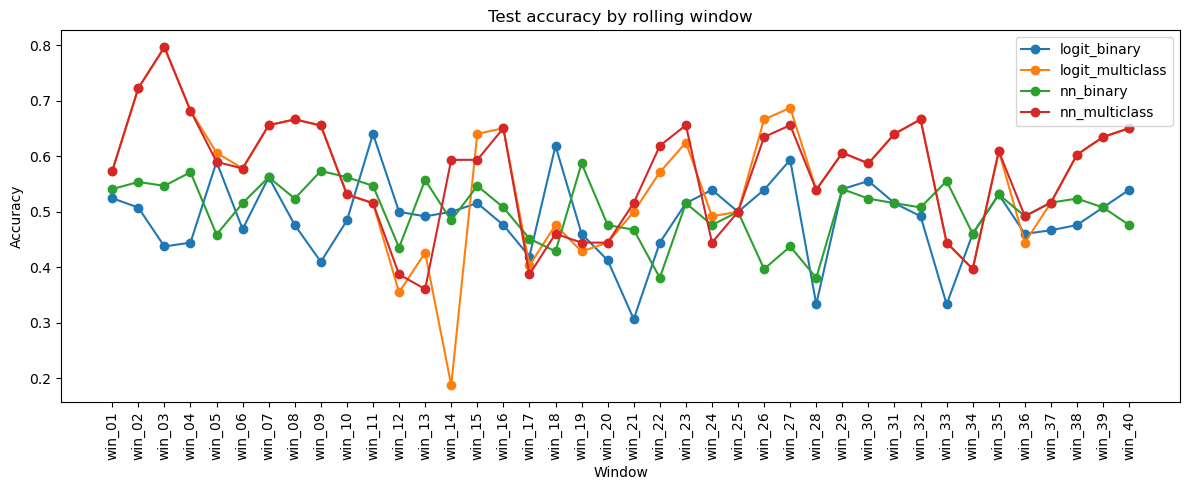

In [13]:
test_acc_by_window = (
    classification_summary[classification_summary["split"] == "test"]
    .sort_values(["model_id", "window_id"])
)

plt.figure(figsize=(12, 5))
for model_id, sub in test_acc_by_window.groupby("model_id"):
    plt.plot(sub["window_id"], sub["accuracy"], marker="o", linewidth=1.5, label=model_id)

plt.title("Test accuracy by rolling window")
plt.xlabel("Window")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
def aggregated_confusion(confusion_summary, split="test"):
    pred_cols = [c for c in confusion_summary.columns if c.startswith("pred_")]
    out = {}
    for model_id, sub in confusion_summary[confusion_summary["split"] == split].groupby("model_id"):
        table = sub.groupby("actual_label")[pred_cols].sum()
        out[model_id] = table
    return out

agg_conf = aggregated_confusion(confusion_summary, split="test")

for model_id, table in agg_conf.items():
    display(Markdown(f"### Aggregated test confusion matrix: `{model_id}`"))
    display(table)


### Aggregated test confusion matrix: `logit_binary`

,pred_0,pred_1,pred_-1
actual_label,,,
actual_0,870,361,0.0000
actual_1,922,363,0.0000


### Aggregated test confusion matrix: `logit_multiclass`

,pred_0,pred_1,pred_-1
actual_label,,,
actual_-1,508,7,23.0000
actual_0,1382,5,54.0000
actual_1,506,4,27.0000


### Aggregated test confusion matrix: `nn_binary`

,pred_0,pred_1,pred_-1
actual_label,,,
actual_0,351,880,0.0000
actual_1,369,916,0.0000


### Aggregated test confusion matrix: `nn_multiclass`

,pred_0,pred_1,pred_-1
actual_label,,,
actual_-1,520,6,12.0000
actual_0,1414,10,17.0000
actual_1,525,4,8.0000


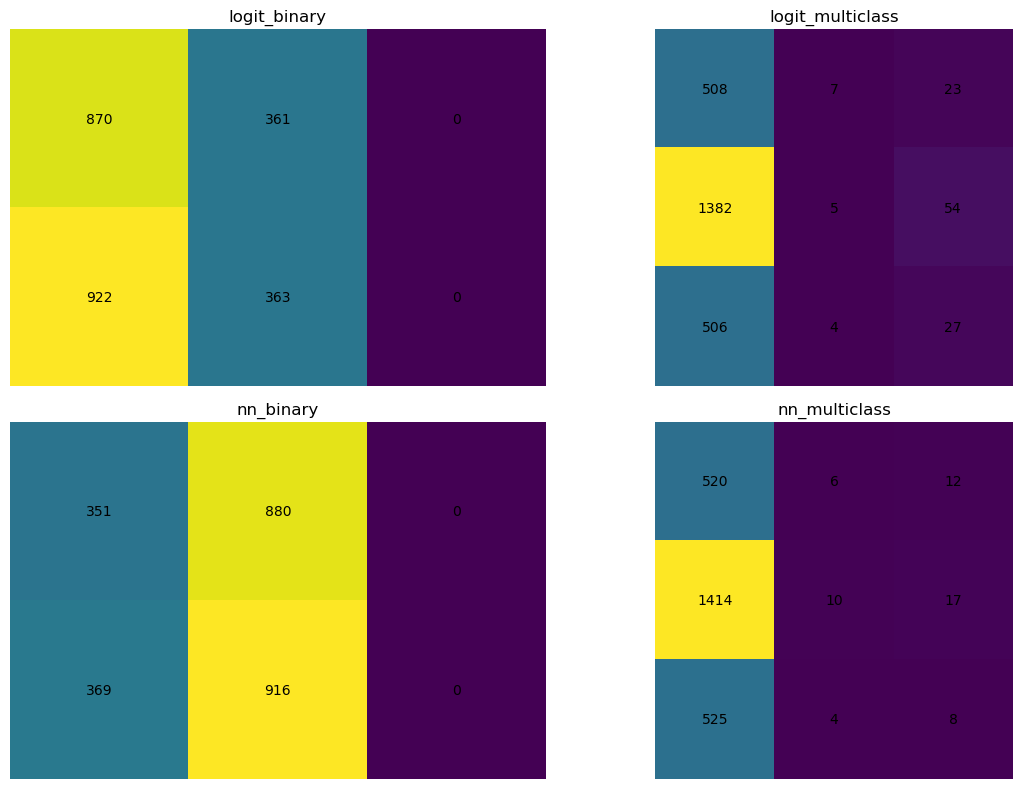

In [15]:
def plot_confusion_tables(conf_dict, ncols=2, figsize=(12, 8)):
    items = list(conf_dict.items())
    n = len(items)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(nrows, ncols)

    for ax in axes.flat:
        ax.axis("off")

    for ax, (model_id, table) in zip(axes.flat, items):
        arr = table.to_numpy()
        im = ax.imshow(arr)
        ax.set_title(model_id)
        ax.set_xticks(range(arr.shape[1]))
        ax.set_yticks(range(arr.shape[0]))
        ax.set_xticklabels(table.columns, rotation=45, ha="right")
        ax.set_yticklabels(table.index)

        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                ax.text(j, i, int(arr[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_tables(agg_conf, ncols=2, figsize=(12, 8))


## 5. Portfolio performance evaluation

In [16]:
portfolio_summary = results["portfolio_summary"].copy()
relative_summary = results["relative_summary"].copy()

display(portfolio_summary.head())
display(relative_summary.head())


,cumulative_return,mean_return,volatility,sharpe,hit_rate,n_obs,active_rate,model_name,class_type,model_id,window_id,split,portfolio_name
0,4.7057,0.0015,0.0179,0.0863,0.5342,"1,258.0000",1.0000,logit,binary,logit_binary,win_01,train,strategy_gross
1,4.2292,0.0015,0.0179,0.0824,0.5326,"1,258.0000",1.0000,logit,binary,logit_binary,win_01,train,strategy_net
2,-0.7315,-0.0009,0.0179,-0.0493,0.4825,"1,258.0000",NaN,logit,binary,logit_binary,win_01,train,benchmark_nvda_minus_tsla
3,1.4833,0.0009,0.0179,0.0493,0.5167,"1,258.0000",NaN,logit,binary,logit_binary,win_01,train,benchmark_tsla_minus_nvda
4,1.1229,0.0008,0.0179,0.0423,0.5016,"1,258.0000",1.0000,logit,binary,logit_binary,win_01,train,benchmark_mom21


,beta,alpha,information_ratio,model_name,class_type,model_id,window_id,split,strategy_name,benchmark_name
0,-0.3531,0.0012,0.0737,logit,binary,logit_binary,win_01,train,strategy_gross,benchmark_nvda_minus_tsla
1,0.1307,0.0014,0.0815,logit,binary,logit_binary,win_01,train,strategy_gross,benchmark_mom21
2,-0.0865,0.0015,0.0854,logit,binary,logit_binary,win_01,train,strategy_gross,benchmark_random_walk
3,-0.3533,0.0012,0.0695,logit,binary,logit_binary,win_01,train,strategy_net,benchmark_nvda_minus_tsla
4,0.1310,0.0014,0.0775,logit,binary,logit_binary,win_01,train,strategy_net,benchmark_mom21


In [17]:
strategy_only = portfolio_summary[portfolio_summary["portfolio_name"].isin(["strategy_gross", "strategy_net"])].copy()
benchmark_only = portfolio_summary[~portfolio_summary["portfolio_name"].isin(["strategy_gross", "strategy_net"])].copy()

strategy_table = (
    strategy_only
    .groupby(["model_id", "split", "portfolio_name"], as_index=False)
    .agg(
        mean_cumulative_return=("cumulative_return", "mean"),
        mean_return=("mean_return", "mean"),
        mean_volatility=("volatility", "mean"),
        mean_sharpe=("sharpe", "mean"),
        mean_hit_rate=("hit_rate", "mean"),
        mean_active_rate=("active_rate", "mean"),
        n_windows=("window_id", "nunique"),
    )
    .sort_values(["split", "portfolio_name", "mean_sharpe"], ascending=[True, True, False])
)

benchmark_table = (
    benchmark_only
    .groupby(["split", "portfolio_name"], as_index=False)
    .agg(
        mean_cumulative_return=("cumulative_return", "mean"),
        mean_return=("mean_return", "mean"),
        mean_volatility=("volatility", "mean"),
        mean_sharpe=("sharpe", "mean"),
        mean_hit_rate=("hit_rate", "mean"),
        n_windows=("window_id", "nunique"),
    )
    .sort_values(["split", "mean_sharpe"], ascending=[True, False])
)

display(Markdown("### Strategy summary"))
display(strategy_table)

display(Markdown("### Benchmark summary"))
display(benchmark_table)


### Strategy summary

,model_id,split,portfolio_name,mean_cumulative_return,mean_return,mean_volatility,mean_sharpe,mean_hit_rate,mean_active_rate,n_windows
12,nn_binary,test,strategy_gross,0.0064,0.0000,0.0180,0.0125,0.5031,1.0000,40
18,nn_multiclass,test,strategy_gross,-0.0019,-0.0000,0.0014,-0.0015,0.0119,0.0227,40
0,logit_binary,test,strategy_gross,-0.0306,-0.0006,0.0180,-0.0244,0.4895,1.0000,40
6,logit_multiclass,test,strategy_gross,-0.0080,-0.0001,0.0015,-0.0693,0.0234,0.0476,40
13,nn_binary,test,strategy_net,0.0026,-0.0000,0.0180,0.0091,0.5027,1.0000,40
19,nn_multiclass,test,strategy_net,-0.0023,-0.0000,0.0014,-0.0067,0.0119,0.0227,40
1,logit_binary,test,strategy_net,-0.0332,-0.0006,0.0180,-0.0269,0.4895,1.0000,40
7,logit_multiclass,test,strategy_net,-0.0082,-0.0001,0.0015,-0.0744,0.0234,0.0476,40
2,logit_binary,train,strategy_gross,3.5020,0.0013,0.0180,0.0704,0.5423,1.0000,40
14,nn_binary,train,strategy_gross,2.2987,0.0009,0.0180,0.0499,0.5265,1.0000,40


### Benchmark summary

,split,portfolio_name,mean_cumulative_return,mean_return,mean_volatility,mean_sharpe,mean_hit_rate,n_windows
0,test,benchmark_mom21,0.0483,0.0007,0.0180,0.0407,0.5183,40
1,test,benchmark_nvda_minus_tsla,0.0264,0.0003,0.0180,0.0249,0.5107,40
2,test,benchmark_random_walk,-0.0093,-0.0002,0.0180,-0.0140,0.4886,40
3,test,benchmark_tsla_minus_nvda,-0.0131,-0.0003,0.0180,-0.0249,0.4889,40
4,train,benchmark_mom21,1.1196,0.0007,0.0180,0.0402,0.5144,40
5,train,benchmark_nvda_minus_tsla,0.0033,0.0000,0.0180,0.0010,0.5053,40
7,train,benchmark_tsla_minus_nvda,-0.0314,-0.0000,0.0180,-0.0010,0.4945,40
6,train,benchmark_random_walk,-0.5392,-0.0005,0.0180,-0.0265,0.4880,40
8,val,benchmark_mom21,0.0551,0.0008,0.0181,0.0469,0.5211,40
9,val,benchmark_nvda_minus_tsla,0.0325,0.0004,0.0180,0.0302,0.5127,40


In [18]:
test_strategy_rank = (
    strategy_table[
        (strategy_table["split"] == "test") &
        (strategy_table["portfolio_name"] == "strategy_net")
    ]
    .sort_values("mean_sharpe", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### Test ranking: net strategy"))
display(test_strategy_rank)


### Test ranking: net strategy

,model_id,split,portfolio_name,mean_cumulative_return,mean_return,mean_volatility,mean_sharpe,mean_hit_rate,mean_active_rate,n_windows
0,nn_binary,test,strategy_net,0.0026,-0.0000,0.0180,0.0091,0.5027,1.0000,40
1,nn_multiclass,test,strategy_net,-0.0023,-0.0000,0.0014,-0.0067,0.0119,0.0227,40
2,logit_binary,test,strategy_net,-0.0332,-0.0006,0.0180,-0.0269,0.4895,1.0000,40
3,logit_multiclass,test,strategy_net,-0.0082,-0.0001,0.0015,-0.0744,0.0234,0.0476,40


In [19]:
relative_test = (
    relative_summary[relative_summary["split"] == "test"]
    .groupby(["model_id", "strategy_name", "benchmark_name"], as_index=False)
    .agg(
        mean_beta=("beta", "mean"),
        mean_alpha=("alpha", "mean"),
        mean_information_ratio=("information_ratio", "mean"),
        n_windows=("window_id", "nunique"),
    )
    .sort_values(["strategy_name", "benchmark_name", "mean_information_ratio"], ascending=[True, True, False])
)

display(relative_test)


,model_id,strategy_name,benchmark_name,mean_beta,mean_alpha,mean_information_ratio,n_windows
12,nn_binary,strategy_gross,benchmark_mom21,0.1060,-0.0001,0.0070,40
18,nn_multiclass,strategy_gross,benchmark_mom21,-0.0001,-0.0000,0.0053,40
0,logit_binary,strategy_gross,benchmark_mom21,-0.2181,-0.0002,-0.0255,40
6,logit_multiclass,strategy_gross,benchmark_mom21,-0.0127,-0.0001,-0.0742,40
1,logit_binary,strategy_gross,benchmark_nvda_minus_tsla,-0.3942,0.0002,0.0163,40
13,nn_binary,strategy_gross,benchmark_nvda_minus_tsla,0.4107,-0.0000,0.0037,40
19,nn_multiclass,strategy_gross,benchmark_nvda_minus_tsla,-0.0133,-0.0000,-0.0030,40
7,logit_multiclass,strategy_gross,benchmark_nvda_minus_tsla,-0.0335,-0.0001,-0.0644,40
14,nn_binary,strategy_gross,benchmark_random_walk,-0.0192,0.0000,0.0128,40
20,nn_multiclass,strategy_gross,benchmark_random_walk,-0.0078,-0.0000,-0.0000,40


## 6. Wealth-curve plots

### Important interpretation note

Because the rolling design uses **overlapping training windows**, a single calendar-time train wealth curve is not well-defined.  
So the notebook uses two plotting conventions:

1. **Calendar-time stitched wealth** for **non-overlapping test windows**  
   This is the clean out-of-sample path.

2. **Average within-window wealth by event time** for train, validation, and test  
   This is useful for comparing train vs. test behavior when windows overlap.


In [20]:
predictions = results["predictions"].copy()

display(predictions.head())
print(predictions[["model_id", "split"]].drop_duplicates().sort_values(["model_id", "split"]).to_string(index=False))


,date,ret_a_next,ret_b_next,spread_t,spread_next,mom21_diff,model_name,class_type,model_id,window_id,split,abs_threshold,y_true,y_pred,signal,is_active,turnover,strategy_gross,strategy_net,prob_0,prob_1,benchmark_nvda_minus_tsla,benchmark_tsla_minus_nvda,benchmark_mom21_signal,benchmark_mom21,benchmark_random_walk_signal,benchmark_random_walk,prob_-1
0,2010-09-28,-0.0076,0.0271,-0.0444,-0.0347,0.0966,logit,binary,logit_binary,win_01,train,NaN,0,0,-1,1,0.0000,0.0174,0.0174,0.5704,0.4296,-0.0174,0.0174,1,-0.0174,-1,0.0174,NaN
1,2010-09-29,-0.0167,-0.0717,-0.0347,0.0550,0.1262,logit,binary,logit_binary,win_01,train,NaN,1,0,-1,1,0.0000,-0.0275,-0.0275,0.5482,0.4518,0.0275,-0.0275,1,0.0275,-1,-0.0275,NaN
2,2010-09-30,-0.0284,0.0096,0.0550,-0.0380,0.2053,logit,binary,logit_binary,win_01,train,NaN,0,0,-1,1,0.0000,0.0190,0.0190,0.5336,0.4664,-0.0190,0.0190,1,-0.0190,1,-0.0190,NaN
3,2010-10-01,-0.0097,0.0189,-0.0380,-0.0286,0.2000,logit,binary,logit_binary,win_01,train,NaN,0,0,-1,1,0.0000,0.0143,0.0143,0.5395,0.4605,-0.0143,0.0143,1,-0.0143,-1,0.0143,NaN
4,2010-10-04,0.0071,0.0062,-0.0286,0.0009,0.1778,logit,binary,logit_binary,win_01,train,NaN,1,0,-1,1,0.0000,-0.0005,-0.0005,0.5448,0.4552,0.0005,-0.0005,1,0.0005,-1,-0.0005,NaN


        model_id split
    logit_binary  test
    logit_binary train
    logit_binary   val
logit_multiclass  test
logit_multiclass train
logit_multiclass   val
       nn_binary  test
       nn_binary train
       nn_binary   val
   nn_multiclass  test
   nn_multiclass train
   nn_multiclass   val


In [21]:
def stitched_split_returns(predictions, split="test", strategy_col="strategy_net"):
    sub = predictions[predictions["split"] == split].copy()
    sub = sub.sort_values(["model_id", "date"])

    stitched = []
    for model_id, g in sub.groupby("model_id"):
        temp = g[["date", strategy_col]].drop_duplicates(subset=["date"]).sort_values("date").copy()
        temp["model_id"] = model_id
        stitched.append(temp)

    return pd.concat(stitched, ignore_index=True)


def stitched_benchmark_returns(predictions, split="test", benchmark_cols=None):
    if benchmark_cols is None:
        benchmark_cols = [
            "benchmark_nvda_minus_tsla",
            "benchmark_mom21",
            "benchmark_random_walk",
        ]

    sub = predictions[predictions["split"] == split].copy()
    keep = ["date"] + benchmark_cols
    bench = sub[keep].drop_duplicates(subset=["date"]).sort_values("date").copy()
    return bench


def plot_calendar_time_wealth(predictions, split="test", strategy_col="strategy_net", include_benchmarks=True):
    stitched = stitched_split_returns(predictions, split=split, strategy_col=strategy_col)

    plt.figure(figsize=(12, 6))
    for model_id, g in stitched.groupby("model_id"):
        plt.plot(g["date"], wealth_index(g[strategy_col]), label=model_id)

    if include_benchmarks:
        bench = stitched_benchmark_returns(predictions, split=split)
        for col in ["benchmark_nvda_minus_tsla", "benchmark_mom21", "benchmark_random_walk"]:
            plt.plot(bench["date"], wealth_index(bench[col]), linestyle="--", label=col)

    plt.title(f"Calendar-time wealth curves: {split} / {strategy_col}")
    plt.xlabel("Date")
    plt.ylabel("Wealth index")
    plt.legend()
    plt.tight_layout()
    plt.show()


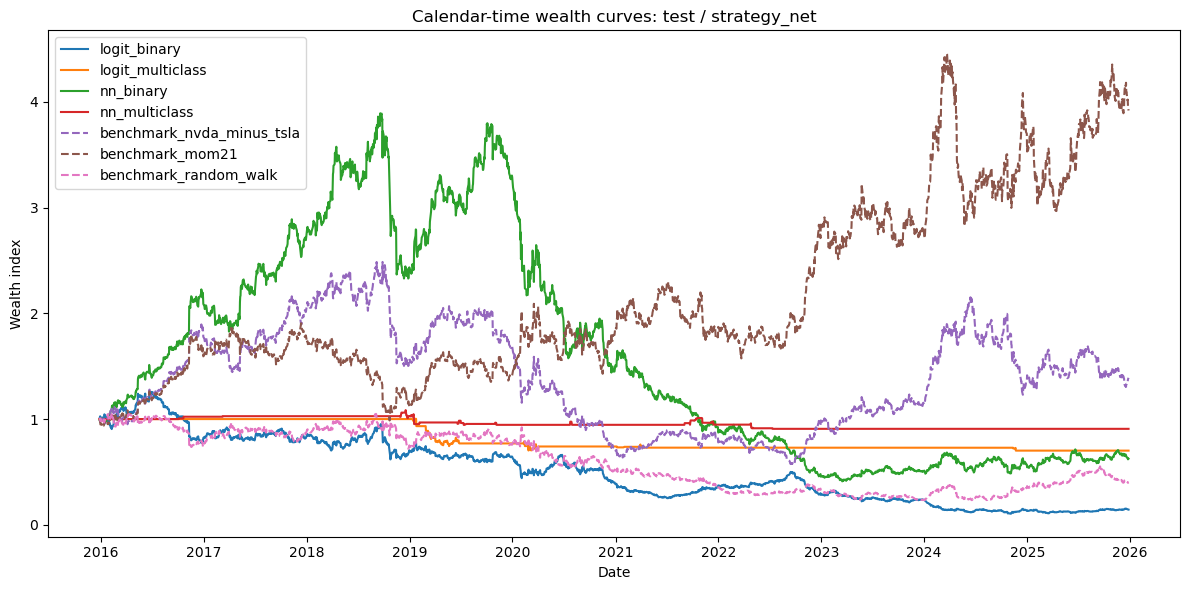

In [22]:
plot_calendar_time_wealth(predictions, split="test", strategy_col="strategy_net", include_benchmarks=True)


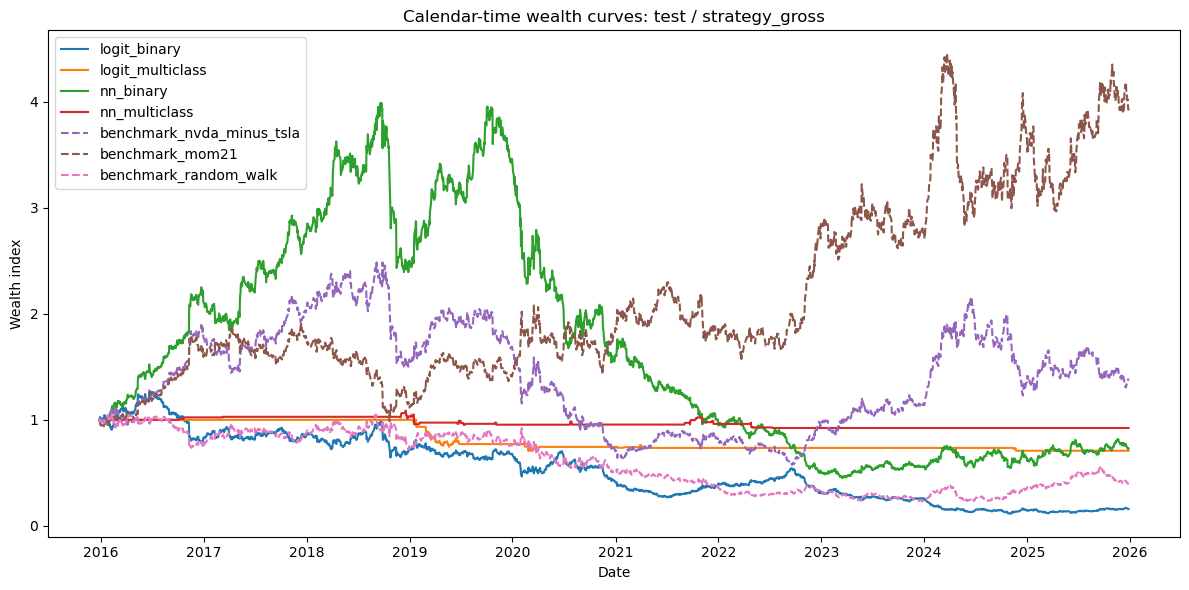

In [23]:
plot_calendar_time_wealth(predictions, split="test", strategy_col="strategy_gross", include_benchmarks=True)


In [24]:
def average_event_time_wealth(predictions, split="train", return_col="strategy_net", benchmark=False, model_id=None):
    if benchmark:
        sub = predictions[predictions["split"] == split][["window_id", "date", return_col]].drop_duplicates().copy()
        grouping_keys = ["window_id"]
    else:
        sub = predictions[(predictions["split"] == split) & (predictions["model_id"] == model_id)][["window_id", "date", return_col]].copy()
        grouping_keys = ["window_id"]

    sub = sub.sort_values(grouping_keys + ["date"]).copy()
    sub["step"] = sub.groupby(grouping_keys).cumcount()
    sub["wealth"] = sub.groupby(grouping_keys)[return_col].transform(lambda s: (1.0 + s).cumprod())

    avg = (
        sub.groupby("step", as_index=False)
        .agg(mean_wealth=("wealth", "mean"))
    )
    return avg


def plot_event_time_wealth(predictions, split="train", strategy_col="strategy_net", include_benchmarks=True):
    model_ids = sorted(predictions["model_id"].unique())

    plt.figure(figsize=(12, 6))
    for model_id in model_ids:
        avg = average_event_time_wealth(predictions, split=split, return_col=strategy_col, benchmark=False, model_id=model_id)
        plt.plot(avg["step"], avg["mean_wealth"], label=model_id)

    if include_benchmarks:
        for col in ["benchmark_nvda_minus_tsla", "benchmark_mom21", "benchmark_random_walk"]:
            avg_b = average_event_time_wealth(predictions, split=split, return_col=col, benchmark=True)
            plt.plot(avg_b["step"], avg_b["mean_wealth"], linestyle="--", label=col)

    plt.title(f"Average within-window wealth: {split} / {strategy_col}")
    plt.xlabel("Days since start of split")
    plt.ylabel("Average wealth index")
    plt.legend()
    plt.tight_layout()
    plt.show()


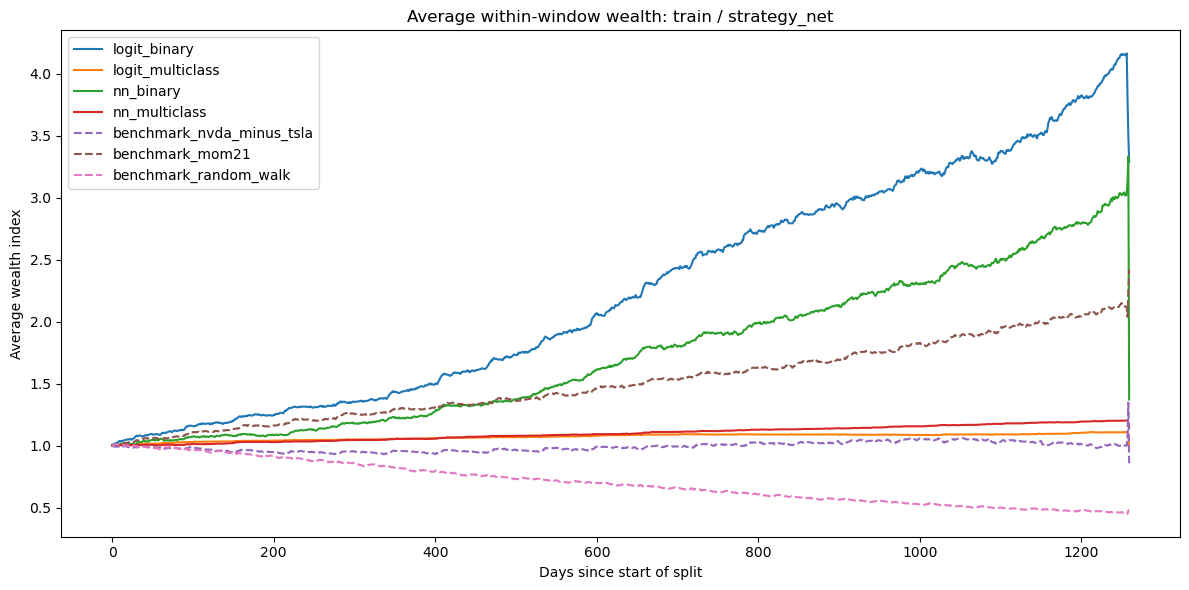

In [25]:
plot_event_time_wealth(predictions, split="train", strategy_col="strategy_net", include_benchmarks=True)


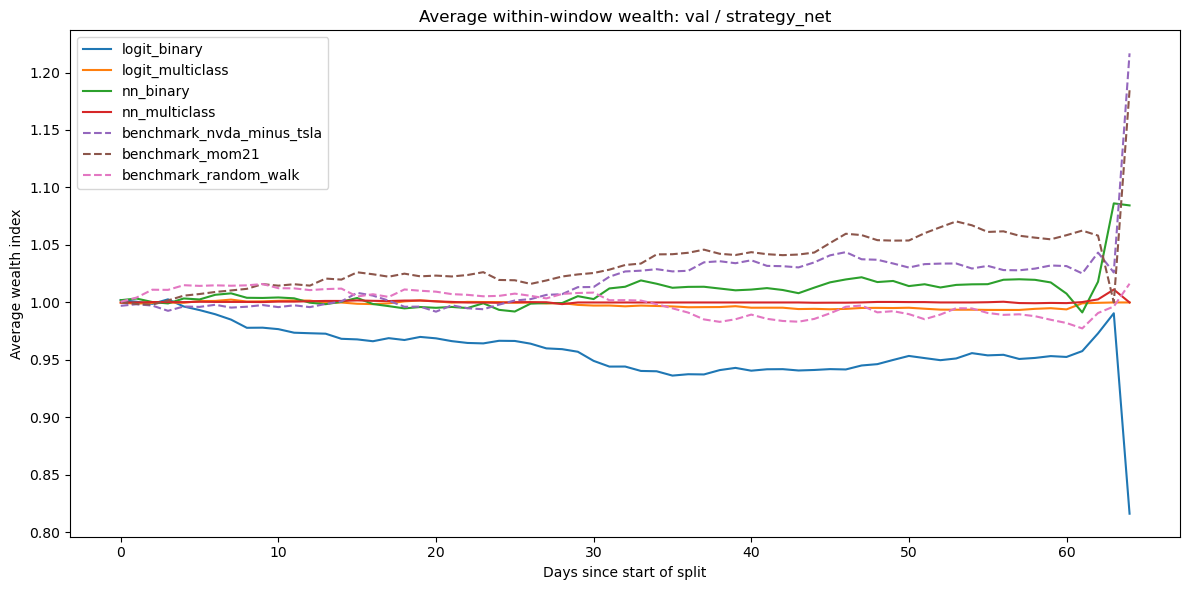

In [26]:
plot_event_time_wealth(predictions, split="val", strategy_col="strategy_net", include_benchmarks=True)


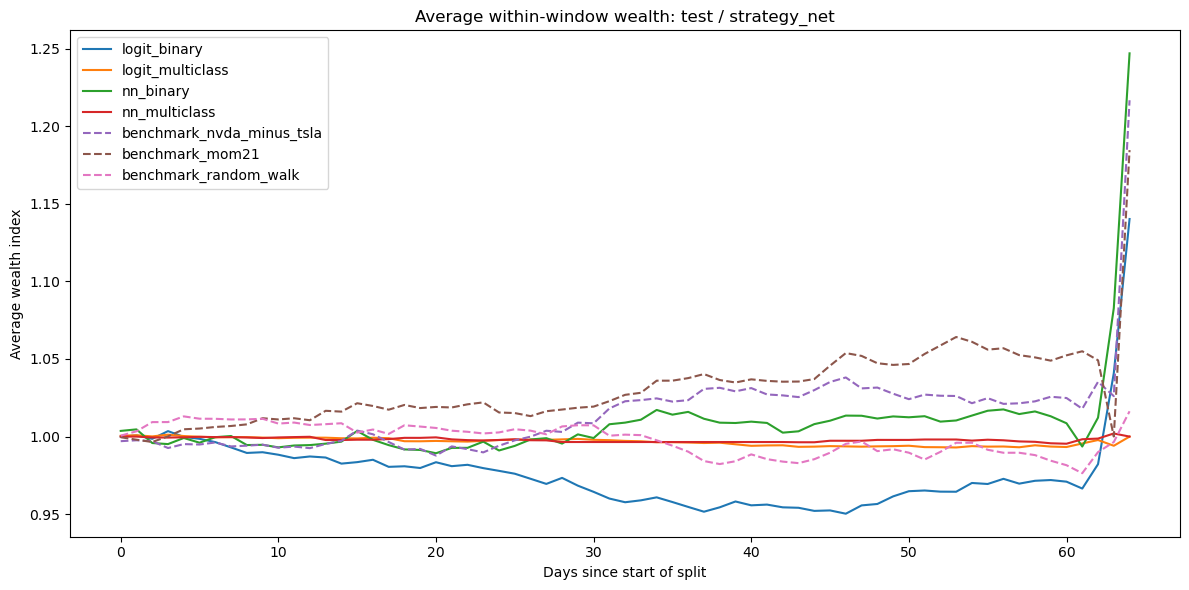

In [27]:
plot_event_time_wealth(predictions, split="test", strategy_col="strategy_net", include_benchmarks=True)


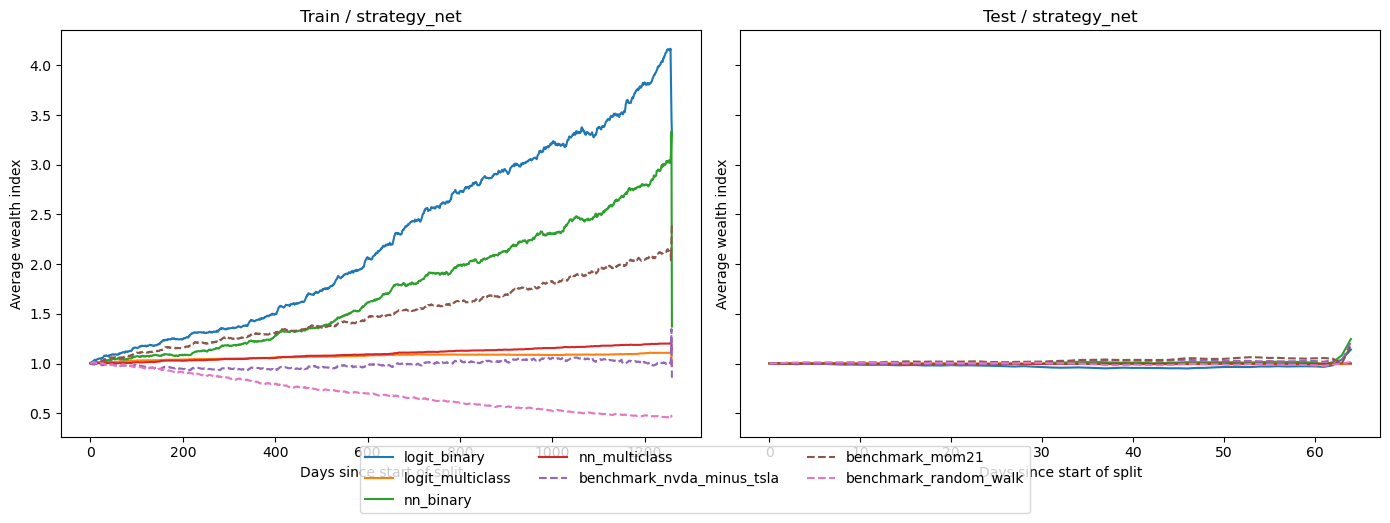

In [28]:
def plot_train_test_side_by_side(predictions, strategy_col="strategy_net"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, split in zip(axes, ["train", "test"]):
        for model_id in sorted(predictions["model_id"].unique()):
            avg = average_event_time_wealth(predictions, split=split, return_col=strategy_col, benchmark=False, model_id=model_id)
            ax.plot(avg["step"], avg["mean_wealth"], label=model_id)

        for col in ["benchmark_nvda_minus_tsla", "benchmark_mom21", "benchmark_random_walk"]:
            avg_b = average_event_time_wealth(predictions, split=split, return_col=col, benchmark=True)
            ax.plot(avg_b["step"], avg_b["mean_wealth"], linestyle="--", label=col)

        ax.set_title(f"{split.capitalize()} / {strategy_col}")
        ax.set_xlabel("Days since start of split")
        ax.set_ylabel("Average wealth index")

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    plt.show()

plot_train_test_side_by_side(predictions, strategy_col="strategy_net")


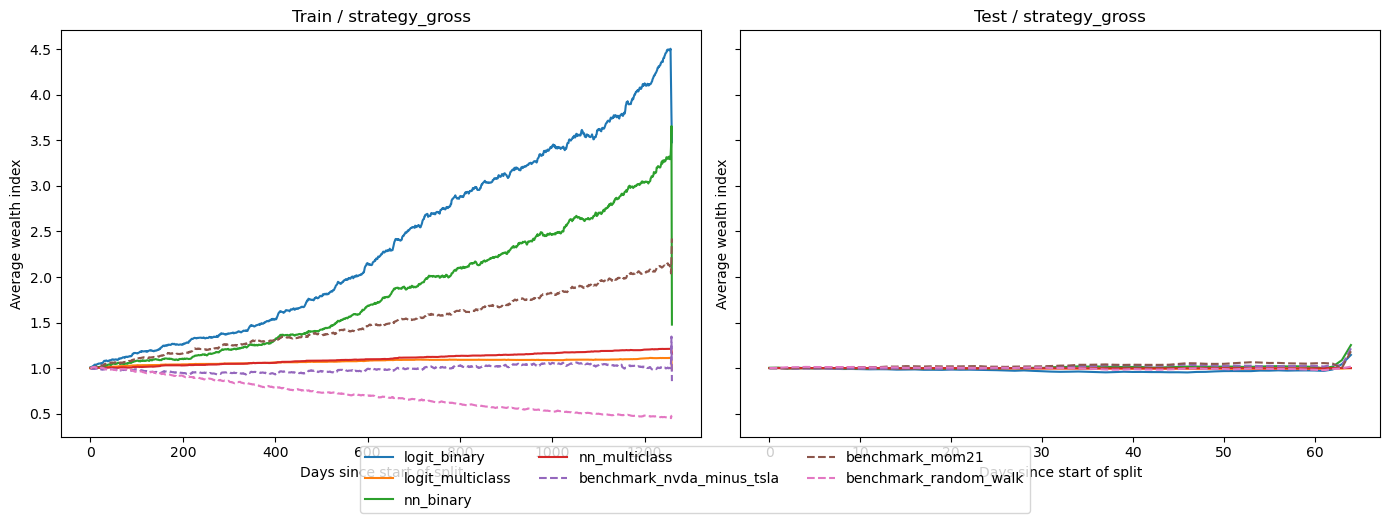

In [29]:
plot_train_test_side_by_side(predictions, strategy_col="strategy_gross")


## 7. Coefficient inspection for logistic regression

In [ ]:
coef_summary = results.get("coefficient_summary", None)

if coef_summary is None:
    print("No coefficient summary returned.")
else:
    display(coef_summary.head())

    coef_mean = (
        coef_summary
        .groupby(["model_id", "class_label", "feature"], as_index=False)
        .agg(mean_coef=("coef", "mean"))
    )

    for model_id in sorted(coef_mean["model_id"].unique()):
        display(Markdown(f"### Average coefficients: `{model_id}`"))
        table = (
            coef_mean[coef_mean["model_id"] == model_id]
            .sort_values(["class_label", "mean_coef"], ascending=[True, False])
        )
        display(table)


,model_name,class_type,model_id,window_id,class_label,feature,coef
0,logit,binary,logit_binary,win_01,1,op_margin_diff,0.1571
1,logit,binary,logit_binary,win_01,1,net_margin_diff,-0.0078
2,logit,binary,logit_binary,win_01,1,leverage_diff,0.1144
3,logit,binary,logit_binary,win_01,1,cash_ratio_diff,-0.0883
4,logit,binary,logit_binary,win_01,1,rnd_intensity_diff,0.0259


### Average coefficients: `logit_binary`

,model_id,class_label,feature,mean_coef
2,logit_binary,1,cash_ratio_diff,0.0854
9,logit_binary,1,net_margin_diff,0.0817
0,logit_binary,1,asset_turnover_diff,0.0804
12,logit_binary,1,rsi14_diff,0.0752
14,logit_binary,1,vol_shock20_diff,0.0444
3,logit_binary,1,leverage_diff,0.0347
1,logit_binary,1,capex_intensity_diff,0.0129
8,logit_binary,1,mom63_diff,0.0071
6,logit_binary,1,mom21_diff,-0.0122
5,logit_binary,1,ma_gap20_diff,-0.0151


### Average coefficients: `logit_multiclass`

,model_id,class_label,feature,mean_coef
25,logit_multiclass,-1,op_margin_diff,0.1299
19,logit_multiclass,-1,log_mcap_diff,0.1140
26,logit_multiclass,-1,rnd_intensity_diff,0.0647
20,logit_multiclass,-1,ma_gap20_diff,0.0527
22,logit_multiclass,-1,mom5_diff,0.0273
17,logit_multiclass,-1,cash_ratio_diff,0.0005
21,logit_multiclass,-1,mom21_diff,-0.0096
29,logit_multiclass,-1,vol_shock20_diff,-0.0122
23,logit_multiclass,-1,mom63_diff,-0.0228
28,logit_multiclass,-1,rv21_diff,-0.0387


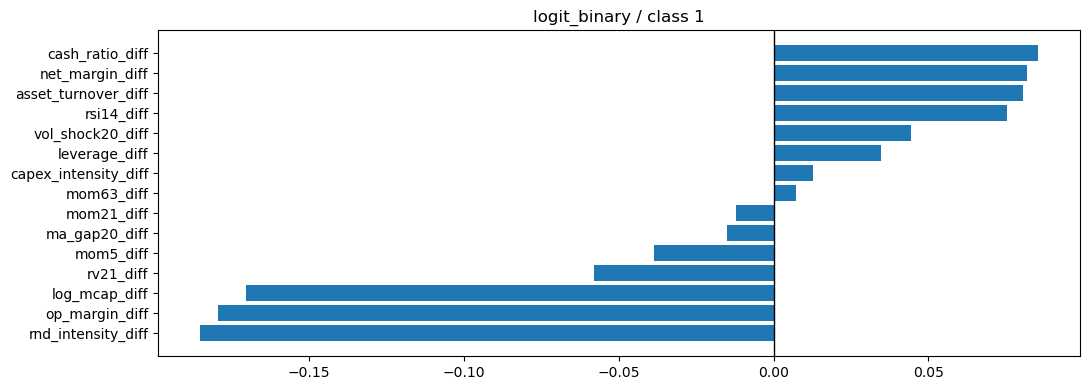

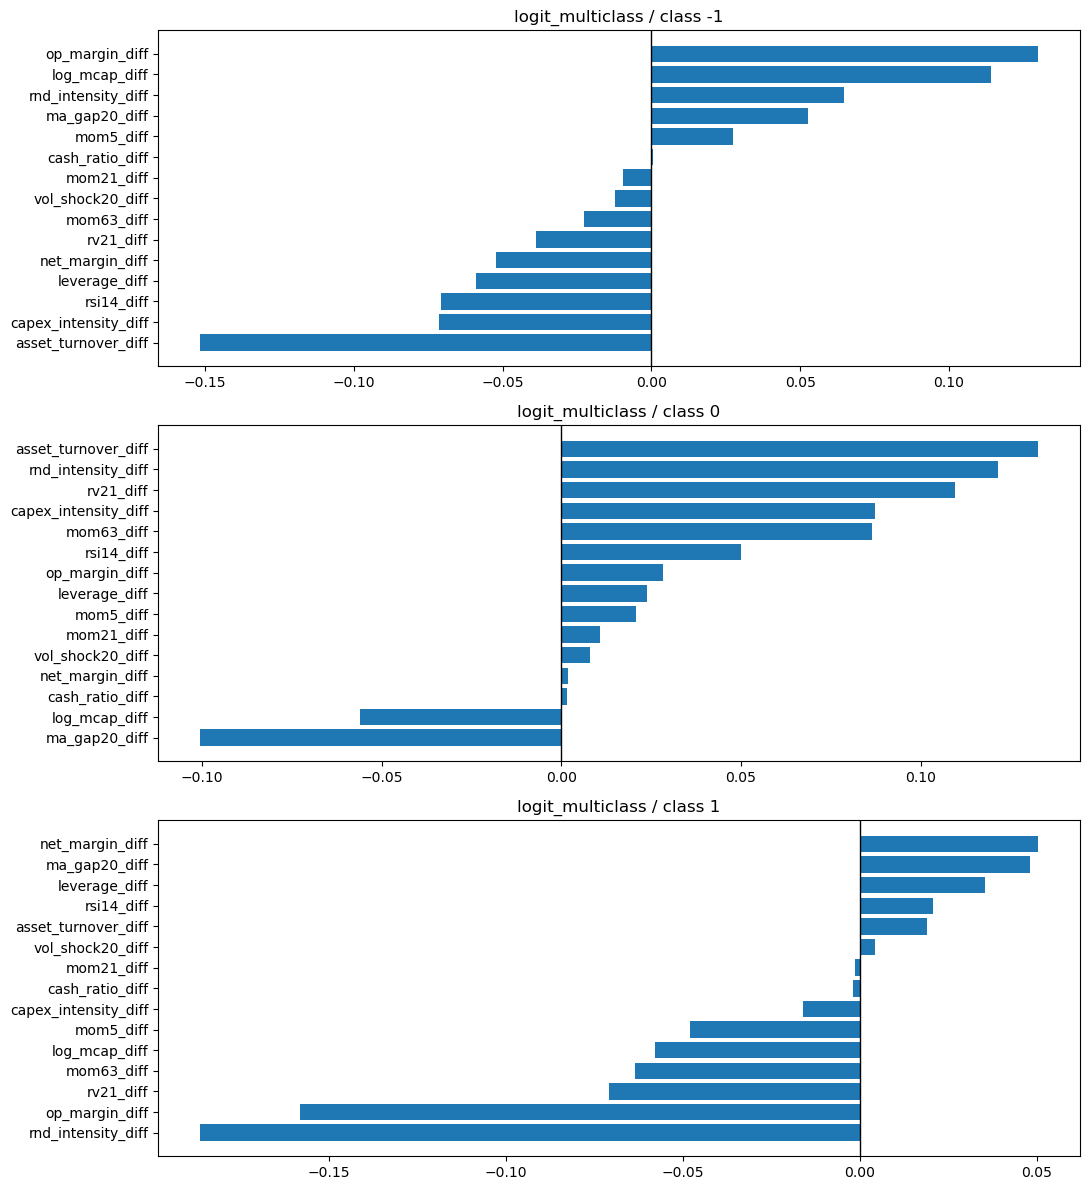

In [31]:
if coef_summary is not None:
    for model_id in sorted(coef_summary["model_id"].unique()):
        temp = (
            coef_summary[coef_summary["model_id"] == model_id]
            .groupby(["class_label", "feature"], as_index=False)
            .agg(mean_coef=("coef", "mean"))
        )

        class_labels = sorted(temp["class_label"].unique())
        fig, axes = plt.subplots(len(class_labels), 1, figsize=(11, 4 * len(class_labels)), sharex=False)
        axes = np.atleast_1d(axes)

        for ax, class_label in zip(axes, class_labels):
            sub = temp[temp["class_label"] == class_label].sort_values("mean_coef")
            ax.barh(sub["feature"], sub["mean_coef"])
            ax.set_title(f"{model_id} / class {class_label}")
            ax.axvline(0.0, color="black", linewidth=1)

        plt.tight_layout()
        plt.show()


## 8. Final output tables already written by the pipeline

In [32]:
output_tables = ROOT / "outputs" / "tables"
output_figures = ROOT / "outputs" / "figures"
output_models = ROOT / "outputs" / "models"

print("Tables folder :", output_tables)
print("Figures folder:", output_figures)
print("Models folder :", output_models)

print("\nTables:")
for p in sorted(output_tables.glob("*")):
    print(" -", p.name)

print("\nFigures:")
for p in sorted(output_figures.glob("*")):
    print(" -", p.name)

print("\nModels:")
for p in sorted(output_models.glob("*")):
    print(" -", p.name)


Tables folder : /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/outputs/tables
Figures folder: /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/outputs/figures
Models folder : /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/outputs/models

Tables:
 - classification_metrics.csv
 - classification_metrics_logit.csv
 - classification_summary_all_models.csv
 - classification_summary_logit_binary.csv
 - classification_summary_logit_multiclass.csv
 - classification_summary_nn_binary.csv
 - classification_summary_nn_multiclass.csv
 - coefficients_all_models.csv
 - coefficients_logit_binary.csv
 - coefficients_logit_multiclass.csv
 - confusion_summary_all_models.csv
 - confusion_summary_logit_binary.csv
 - confusion_summary_logit_multiclass.csv
 - confusion_summary_nn_binary.csv
 - confusion_summary_nn_multiclass.csv
 - confusion_test.csv
 - confusion_train.csv
 - logit_coefficients.csv
 - logit_coefficients_logi